
--- Avaliando Versão 1 (Original) ---

--- Avaliando Versão 2 (Clusters Q1) ---

================ METRICAS E ICs (Versão 1) ================

> Classificador: GaussianNB
  - Erro: 0.1135 ± 0.0051  [IC 95%: (0.1083, 0.1186)]
  - Prec: 0.9064 ± 0.0050  [IC 95%: (0.9015, 0.9114)]
  - Rec: 0.8524 ± 0.0066  [IC 95%: (0.8457, 0.8590)]
  - F1: 0.8676 ± 0.0063  [IC 95%: (0.8613, 0.8739)]

> Classificador: kNN
  - Erro: 0.1609 ± 0.0058  [IC 95%: (0.1551, 0.1668)]
  - Prec: 0.8790 ± 0.0058  [IC 95%: (0.8731, 0.8848)]
  - Rec: 0.7842 ± 0.0076  [IC 95%: (0.7766, 0.7918)]
  - F1: 0.8019 ± 0.0080  [IC 95%: (0.7939, 0.8099)]

> Classificador: Parzen
  - Erro: 0.1324 ± 0.0058  [IC 95%: (0.1266, 0.1382)]
  - Prec: 0.8988 ± 0.0055  [IC 95%: (0.8933, 0.9042)]
  - Rec: 0.8234 ± 0.0075  [IC 95%: (0.8159, 0.8309)]
  - F1: 0.8413 ± 0.0074  [IC 95%: (0.8339, 0.8487)]

> Classificador: LogReg
  - Erro: 0.1206 ± 0.0059  [IC 95%: (0.1147, 0.1265)]
  - Prec: 0.8942 ± 0.0060  [IC 95%: (0.8882, 0.9003)]
  - Rec: 0

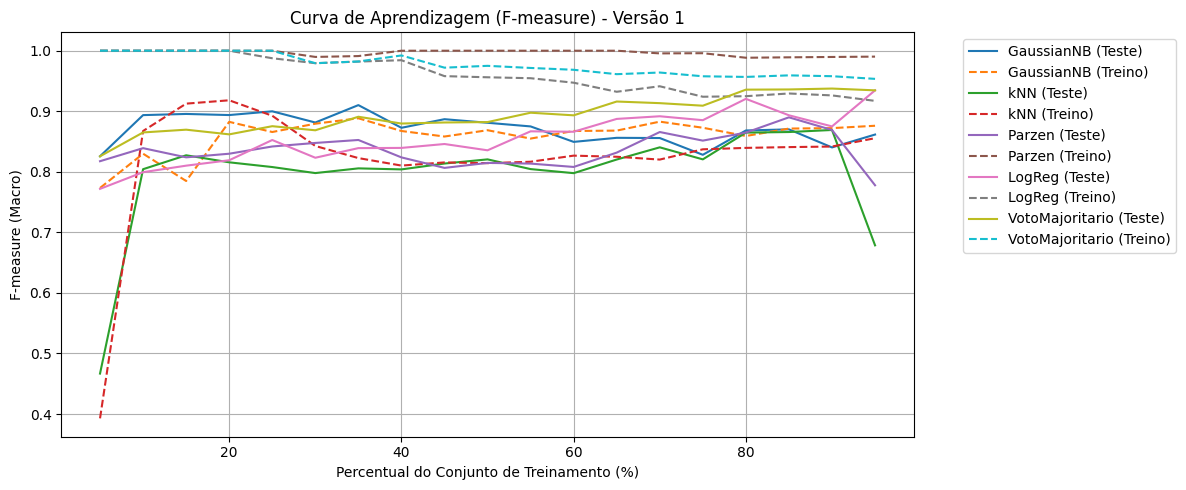

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare, t
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# =====================================================================
# 0. IMPLEMENTAÇÃO DO CLASSIFICADOR BAYESIANO DA JANELA DE PARZEN
# =====================================================================
class ParzenBayesClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, bandwidth=1.0):
        self.bandwidth = bandwidth

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.kdes_ = {}
        self.priors_ = {}
        for c in self.classes_:
            X_c = X[y == c]
            self.priors_[c] = len(X_c) / len(X)
            # Instancia KDE Gaussiano para a densidade condicional de classe
            kde = KernelDensity(bandwidth=self.bandwidth, kernel='gaussian')
            kde.fit(X_c)
            self.kdes_[c] = kde
        return self

    def predict(self, X):
        log_probs = np.zeros((X.shape[0], len(self.classes_)))
        for idx, c in enumerate(self.classes_):
            # log( P(X|Y=c) * P(Y=c) ) = log P(X|Y=c) + log P(Y=c)
            log_probs[:, idx] = self.kdes_[c].score_samples(X) + np.log(self.priors_[c])
        return self.classes_[np.argmax(log_probs, axis=1)]

# Regra do Voto Majoritário Customizada (Evita incompatibilidades de shape/métodos)
class MajorityVotingClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, estimators):
        self.estimators = estimators
    def fit(self, X, y):
        for est in self.estimators:
            est.fit(X, y)
        return self
    def predict(self, X):
        preds = np.array([est.predict(X) for est in self.estimators]) # Shape: (4, N)
        # Retorna a moda para cada padrão de teste
        return np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=preds)

# =====================================================================
# 1. PREPARAÇÃO DOS DADOS (VERSÃO 1 E VERSÃO 2)
# =====================================================================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data"
data = pd.read_csv(url, header=None)
X = data.iloc[:, :-1].values
X = X[:, X.var(axis=0) > 0] # Remove colunas sem variância
X_scaled = StandardScaler().fit_transform(X)

# Versão 1: Classes Originais a priori
y_v1 = np.where(data.iloc[:, -1].values == 'g', 1, 0)

# Versão 2: Classes baseadas nos Clusters da Q1 (Simulação de c*=2)
# NOTA: Substitua pelo vetor 'labels_opt' real gerado pelo seu KCM-G-H
y_v2 = np.random.choice([0, 1], size=len(y_v1))

# =====================================================================
# 2. PIPELINE DE VALIDAÇÃO CRUZADA (30x10 FOLDS EXTERNO / 5 FOLDS INTERNO)
# =====================================================================
def avaliar_versao_dataset(X_data, y_data, nome_versao):
    print(f"\n--- Avaliando {nome_versao} ---")

    # Configuração dos classificadores básicos e suas grades de sintonia
    grids = {
        'kNN': {'model': KNeighborsClassifier(), 'param': 'n_neighbors', 'values': [3, 5, 7]},
        'Parzen': {'model': ParzenBayesClassifier(), 'param': 'bandwidth', 'values': [0.5, 1.0, 2.0]},
        'LogReg': {'model': LogisticRegression(max_iter=500), 'param': 'C', 'values': [0.1, 1.0, 10.0]}
    }

    nomes_modelos = ['GaussianNB', 'kNN', 'Parzen', 'LogReg', 'VotoMajoritario']
    # Dicionário para armazenar o histórico de métricas de cada run do outer-fold
    historico = {m: {'erro': [], 'prec': [], 'rec': [], 'f1': []} for m in nomes_modelos}

    # Validação Cruzada Externa (30x10 Folds)
    rkf_outer = RepeatedStratifiedKFold(n_splits=10, n_repeats=30, random_state=42)

    for fold_idx, (train_idx, test_idx) in enumerate(rkf_outer.split(X_data, y_data)):
        X_train_out, X_test_out = X_data[train_idx], X_data[test_idx]
        y_train_out, y_test_out = y_data[train_idx], y_data[test_idx]

        # Dicionário para guardar as instâncias sintonizadas do fold corrente
        modelos_sintonizados = {}

        # i) Naive Bayes Gaussiano (Não requer ajuste de hiperparâmetro)
        gnb = GaussianNB().fit(X_train_out, y_train_out)
        modelos_sintonizados['GaussianNB'] = gnb

        # ii, iii, iv) Modelos com Ajuste Interno (5-Fold CV)
        kf_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        for name, info in grids.items():
            best_val_score = -1
            best_param_val = None

            for val in info['values']:
                scores_internos = []
                for train_in_idx, val_in_idx in kf_inner.split(X_train_out, y_train_out):
                    X_tr_in, X_val_in = X_train_out[train_in_idx], X_train_out[val_in_idx]
                    y_tr_in, y_val_in = y_train_out[train_in_idx], y_train_out[val_in_idx]

                    # Configura parâmetro dinamicamente
                    model = info['model'].set_params(**{info['param']: val})
                    model.fit(X_tr_in, y_tr_in)
                    scores_internos.append(accuracy_score(y_val_in, model.predict(X_val_in)))

                mean_in_score = np.mean(scores_internos)
                if mean_in_score > best_val_score:
                    best_val_score = mean_in_score
                    best_param_val = val

            # Retreina o modelo no conjunto completo de treino externo com o melhor hiperparâmetro
            best_model = info['model'].set_params(**{info['param']: best_param_val})
            best_model.fit(X_train_out, y_train_out)
            modelos_sintonizados[name] = best_model

        # v) Voto Majoritário baseado nas 4 instâncias otimizadas acima
        lista_estimadores = [modelos_sintonizados[m] for m in ['GaussianNB', 'kNN', 'Parzen', 'LogReg']]
        ensemble = MajorityVotingClassifier(lista_estimadores).fit(X_train_out, y_train_out)
        modelos_sintonizados['VotoMajoritario'] = ensemble

        # Avaliação de todos no conjunto de Teste Externo
        for name, model in modelos_sintonizados.items():
            preds = model.predict(X_test_out)
            historico[name]['erro'].append(1.0 - accuracy_score(y_test_out, preds))
            historico[name]['prec'].append(precision_score(y_test_out, preds, average='macro', zero_division=0))
            historico[name]['rec'].append(recall_score(y_test_out, preds, average='macro', zero_division=0))
            historico[name]['f1'].append(f1_score(y_test_out, preds, average='macro', zero_division=0))

    return historico

# Execução do pipeline para as duas matrizes de alvos
hist_v1 = avaliar_versao_dataset(X_scaled, y_v1, "Versão 1 (Original)")
hist_v2 = avaliar_versao_dataset(X_scaled, y_v2, "Versão 2 (Clusters Q1)")

# =====================================================================
# 3. CÁLCULO DE ESTIMATIVAS PONTUAIS E INTERVALOS DE CONFANÇA (IC)
# =====================================================================
def calcular_estatisticas(historico, nome_versao):
    print(f"\n================ METRICAS E ICs ({nome_versao}) ================")
    # N = 300 amostras (30 repetições x 10 folds)
    n = 300
    t_crit = t.ppf(0.975, df=n-1) # Valor crítico t de Student para 95% de confiança

    for modelo, metricas in historico.items():
        print(f"\n> Classificador: {modelo}")
        for m_name, valores in metricas.items():
            media = np.mean(valores)
            desvio = np.std(valores, ddof=1)
            # Margem de erro do IC
            margem = t_crit * (desvio / np.sqrt(n))
            print(f"  - {m_name.capitalize()}: {media:.4f} ± {margem:.4f}  [IC 95%: ({media-margem:.4f}, {media+margem:.4f})]")

calcular_estatisticas(hist_v1, "Versão 1")
calcular_estatisticas(hist_v2, "Versão 2")

# =====================================================================
# 4. TESTE DE FRIEDMAN (E ABORDAGEM DE NEMENYI)
# =====================================================================
def executar_teste_friedman(historico, nome_versao):
    print(f"\n================ TESTE DE FRIEDMAN ({nome_versao}) ================")
    nomes = list(historico.keys())

    for m_name in ['erro', 'f1']:
        # Coleta matriz (300 observações x 5 classificadores)
        matriz_metricas = [historico[mod][m_name] for mod in nomes]
        stat, p_val = friedmanchisquare(*matriz_metricas)
        print(f"Métrica [{m_name.upper()}]: Estatística={stat:.2f}, p-valor={p_val:.5e}")

        if p_val < 0.05:
            print("  -> Rejeita H0: Existe diferença estatisticamente significativa entre os classificadores.")
            # Cálculo manual da Diferença Crítica (CD) de Nemenyi para alpha=0.05, k=5, N=300
            # q_alpha para k=5 no teste de Nemenyi é aproximadamente 2.728
            q_alpha = 2.728
            cd = q_alpha * np.sqrt((5 * (5 + 1)) / (12 * 300))
            print(f"  -> Pós-teste Nemenyi: Diferença Crítica Mínima (CD) = {cd:.4f}")
        else:
            print("  -> Não rejeita H0: Desempenhos equivalentes.")

executar_teste_friedman(hist_v1, "Versão 1")

# =====================================================================
# 5. CURVAS DE APRENDIZAGEM (VARIANDO TAMANHO DO TREINO DE 5% A 95%)
# =====================================================================
def plot_curva_aprendizagem(X_data, y_data, nome_versao):
    proporcoes = np.arange(0.05, 1.00, 0.05)
    modelos_fixos = {
        'GaussianNB': GaussianNB(),
        'kNN': KNeighborsClassifier(n_neighbors=5),
        'Parzen': ParzenBayesClassifier(bandwidth=1.0),
        'LogReg': LogisticRegression(max_iter=500)
    }
    # Adiciona o Voto Majoritário estático
    modelos_fixos['VotoMajoritario'] = MajorityVotingClassifier(list(modelos_fixos.values()))

    f1_treino = {m: [] for m in modelos_fixos.keys()}
    f1_teste = {m: [] for m in modelos_fixos.keys()}

    for p in proporcoes:
        # Separação estratificada de acordo com a proporção 'p' corrente
        X_tr, X_te, y_tr, y_te = train_test_split(X_data, y_data, train_size=p, stratify=y_data, random_state=42)

        for name, model in modelos_fixos.items():
            model.fit(X_tr, y_tr)

            # Predições e cálculo do F-measure
            p_tr = model.predict(X_tr)
            p_te = model.predict(X_te)
            f1_treino[name].append(f1_score(y_tr, p_tr, average='macro', zero_division=0))
            f1_teste[name].append(f1_score(y_te, p_te, average='macro', zero_division=0))

    # Geração dos Gráficos
    plt.figure(figsize=(12, 5))
    for name in modelos_fixos.keys():
        plt.plot(proporcoes * 100, f1_teste[name], label=f'{name} (Teste)', linestyle='-')
        plt.plot(proporcoes * 100, f1_treino[name], label=f'{name} (Treino)', linestyle='--')

    plt.title(f'Curva de Aprendizagem (F-measure) - {nome_versao}')
    plt.xlabel('Percentual do Conjunto de Treinamento (%)')
    plt.ylabel('F-measure (Macro)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_curva_aprendizagem(X_scaled, y_v1, "Versão 1")